In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv("AmesHousing.csv")
x_raw = df['Gr Liv Area'].values
y_raw = df['SalePrice'].values


In [12]:
x = (x_raw - np.mean(x_raw)) / np.std(x_raw)
y = (y_raw - np.mean(y_raw)) / np.std(y_raw)

print(f"First 5 normalized x values: {x[:5]}")
print(f"First 5 normalized y values: {y[:5]}")

First 5 normalized x values: [ 0.30926506 -1.19442705 -0.33771825  1.20752324  0.25584442]
First 5 normalized y values: [ 0.42822875 -0.94895652 -0.11012549  0.79130487  0.11398011]


###  Mathematical Formulations & Derivatives

To implement first-order (Gradient Descent) and second-order (Newton's Method) optimization, we must mathematically define our model, loss function, and their derivatives.

**1. The Model and Loss Function**
We are fitting a linear model to our data:
$$f(x) = a_0 + a_1x$$

Our objective is to minimize the Convex Loss Function (Sum of Squared Errors):
$$L = \frac{1}{2} \sum_{i=1}^{N} (y_i - (a_0 + a_1 x_i))^2$$

---

**2. First-Order Derivatives: The Gradient (Jacobian)**
Gradient Descent requires the first derivatives of the loss function with respect to our parameters $a_0$ and $a_1$. Using the chain rule, we derive:

* **Partial derivative with respect to $a_0$:**
$$\frac{\partial L}{\partial a_0} = \sum_{i=1}^{N} -1 \cdot (y_i - (a_0 + a_1 x_i)) = \sum_{i=1}^{N} (\hat{y}_i - y_i)$$

* **Partial derivative with respect to $a_1$:**
$$\frac{\partial L}{\partial a_1} = \sum_{i=1}^{N} -x_i \cdot (y_i - (a_0 + a_1 x_i)) = \sum_{i=1}^{N} x_i (\hat{y}_i - y_i)$$

*Conceptually:* The Gradient acts as a compass, pointing in the direction of the steepest ascent. We subtract the gradient (scaled by a learning rate $\alpha$) to step "downhill" toward the minimum error.

---

**3. Second-Order Derivatives: The Hessian Matrix**
Newton's Method requires the second derivatives, which capture the *curvature* of the loss function. We calculate this by taking the derivatives of our first derivatives.

Since our model is purely linear, differentiating the terms again removes the variables $a_0$, $a_1$, and $y_i$, leaving only data constants:

* **Top-Left (Derivative of $a_0$ w.r.t $a_0$):** $H_{00} = \frac{\partial^2 L}{\partial a_0^2} = \sum_{i=1}^{N} 1 = N$
* **Top-Right / Bottom-Left (Cross derivatives):** $H_{01} = H_{10} = \frac{\partial^2 L}{\partial a_0 \partial a_1} = \sum_{i=1}^{N} x_i$
* **Bottom-Right (Derivative of $a_1$ w.r.t $a_1$):** $H_{11} = \frac{\partial^2 L}{\partial a_1^2} = \sum_{i=1}^{N} x_i^2$

This results in the 2x2 Hessian Matrix ($H$):
$$H = \begin{bmatrix} N & \sum x_i \\ \sum x_i & \sum x_i^2 \end{bmatrix}$$

*Conceptually:* Because the Hessian matrix for this basic linear regression contains only constant data terms (no weights), the curvature of the loss surface is a perfect, constant bowl. This allows Newton's Method to mathematically "see" the exact bottom of the bowl and jump there incredibly fast.

In [13]:
def predict(x, a0, a1):
    return a0 + a1 * x

def calculate_loss(x, y, a0, a1):
    y_pred = predict(x, a0, a1)
    # 0.5 * sum of squared differences
    return 0.5 * np.sum((y - y_pred) ** 2)

def calculate_gradient(x, y, a0, a1):
    y_pred = predict(x, a0, a1)
    error = y_pred - y
    # Partial derivatives
    grad_a0 = np.sum(error)
    grad_a1 = np.sum(error * x)

    return np.array([[grad_a0], [grad_a1]])

def calculate_hessian(x):
    N = len(x)
    sum_x = np.sum(x)
    sum_x_squared = np.sum(x ** 2)

    hessian = np.array([
        [N, sum_x],
        [sum_x, sum_x_squared]
    ])

    return hessian

In [14]:
def gradient_descent(x, y, a0_init, a1_init, alpha, max_iter=1000, tolerance=1e-6):
    a0 = a0_init
    a1 = a1_init
    # Dictionary to keep track of our path for plotting later
    history = {'a0': [], 'a1': [], 'loss': []}

    for i in range(max_iter):
        loss = calculate_loss(x, y, a0, a1)
        history['a0'].append(a0)
        history['a1'].append(a1)
        history['loss'].append(loss)
        gradients = calculate_gradient(x, y, a0, a1)
        gradient_a0 = gradients[0][0]
        gradient_a1 = gradients[1][0]

        a0_new = a0 - alpha * gradient_a0
        a1_new = a1 - alpha * gradient_a1

        if abs(a1_new - a1) < tolerance and abs(a0_new - a0) < tolerance:
            history['a0'].append(a0_new)
            history['a1'].append(a1_new)
            history['loss'].append(calculate_loss(x, y, a0_new, a1_new))
            print(f"Grradient descent converged in {i + 1} iterations")
            return a0_new, a1_new, history
        a0 = a0_new
        a1 = a1_new

    print(f"Gradient descent reached max iterations({max_iter}) without convergence.")
    return a0, a1, history


def newtons_method(x, y, a0_init, a1_init, alpha, max_iter=1000, tolerance=1e-6):
    a = np.array([[a0_init], [a1_init]])
    H = calculate_hessian(x)
    H_inverse = np.linalg.inv(H)
    history = {'a0':[] , 'a1':[] , 'loss':[]}
    for i in range(max_iter):
        a0, a1 = a[0][0], a[1][0]
        loss = calculate_loss(x, y, a0, a1)
        history['a0'].append(a0)
        history['a1'].append(a1)
        history['loss'].append(loss)
        J = calculate_gradient(x, y, a0, a1)
        a_new = a - alpha * (H_inverse @ J)

        if np.max(np.abs(a_new - a)) < tolerance:
            history['a0'].append(a_new[0][0])
            history['a1'].append(a_new[1][0])
            history['loss'].append(calculate_loss(x, y, a_new[0][0], a_new[1][0]))
            print(f"Newton's Method converged in {i+1} iterations.")
            return a_new[0][0], a_new[1][0], history
        a = a_new

    print(f"Newton's Method stopped at max iterations ({max_iter}).")
    return a[0][0], a[1][0], history

In [15]:
a0_init, a1_init = 0.0, 0.0

alpha_good = 0.0001
print("--- Gradient Descent (Good Learning Rate) ---")
gd_a0, gd_a1, gd_history = gradient_descent(x, y, a0_init, a1_init, alpha_good)

alpha_small = 0.000005
print("\n--- Gradient Descent (Too Small Learning Rate) ---")
gd_a0_s, gd_a1_s, gd_history_small = gradient_descent(x, y, a0_init, a1_init, alpha_small)

alpha_large = 0.001
print("\n--- Gradient Descent (Too Large Learning Rate) ---")
gd_a0_l, gd_a1_l, gd_history_large = gradient_descent(x, y, a0_init, a1_init, alpha_large, max_iter=100)

alpha_newton = 1.0
print("\n--- Newton's Method ---")
nm_a0, nm_a1, nm_history = newtons_method(x, y, a0_init, a1_init, alpha_newton)

print("\n==========================================")
print("Final Weights (Good GD):", round(gd_a0, 4), round(gd_a1, 4))
print("Final Weights (Newton) :", round(nm_a0, 4), round(nm_a1, 4))

--- Gradient Descent (Good Learning Rate) ---
Grradient descent converged in 37 iterations

--- Gradient Descent (Too Small Learning Rate) ---
Grradient descent converged in 628 iterations

--- Gradient Descent (Too Large Learning Rate) ---
Gradient descent reached max iterations(100) without convergence.

--- Newton's Method ---
Newton's Method converged in 2 iterations.

Final Weights (Good GD): -0.0 0.7068
Final Weights (Newton) : -0.0 0.7068


### Plotting

In [16]:
def plot_loss_path(history, title="Loss Path", step=1):
    losses = np.array(history['loss'])
    a0s    = np.array(history['a0'])
    a1s    = np.array(history['a1'])

    # Use a1 as the x-axis (weight), loss as y-axis — like the diagram
    fig, ax = plt.subplots(figsize=(9, 5))

    # Smooth loss curve: sweep a1 from min to max and plot loss vs a1
    a1_range = np.linspace(a1s.min() - 0.1, a1s.max() + 0.1, 300)
    curve_losses = [calculate_loss(x, y, np.mean(a0s), a1_val) for a1_val in a1_range]
    ax.plot(a1_range, curve_losses, color='steelblue', linewidth=2.5, zorder=1)

    # Arrows + dots along the actual path
    indices = list(range(0, len(losses) - 1, step)) 
    for i in indices:
        ax.annotate(
            "",
            xy=(a1s[i+1], losses[i+1]),
            xytext=(a1s[i], losses[i]),
            arrowprops=dict(arrowstyle="->", color="tomato", lw=1.5),
            zorder=3
        )
    ax.scatter(a1s[::step], losses[::step], color='tomato', s=40, zorder=4)

    # Mark start and end
    ax.scatter(a1s[0],  losses[0],  color='black', s=100, zorder=5, label='Start')
    ax.scatter(a1s[-1], losses[-1], color='gold',  s=100, zorder=5, label='End (Min)', edgecolors='black')

    ax.set_title(title)
    ax.set_xlabel("a₁ (weight)")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

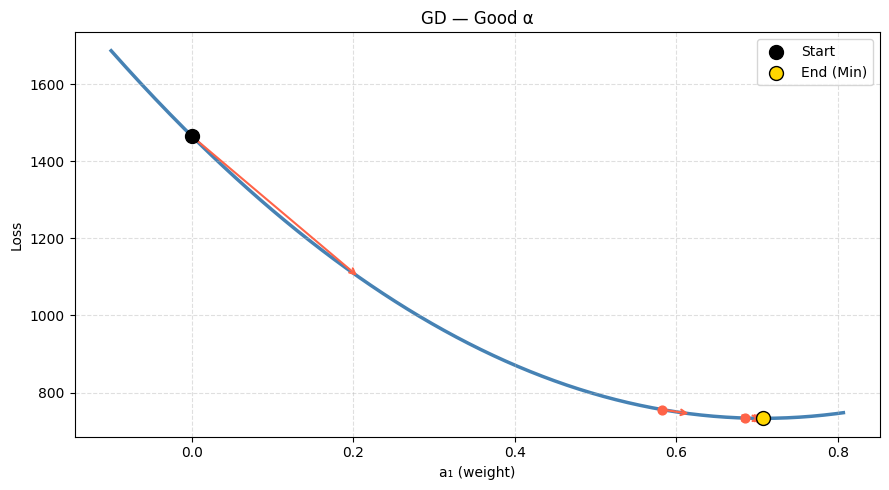

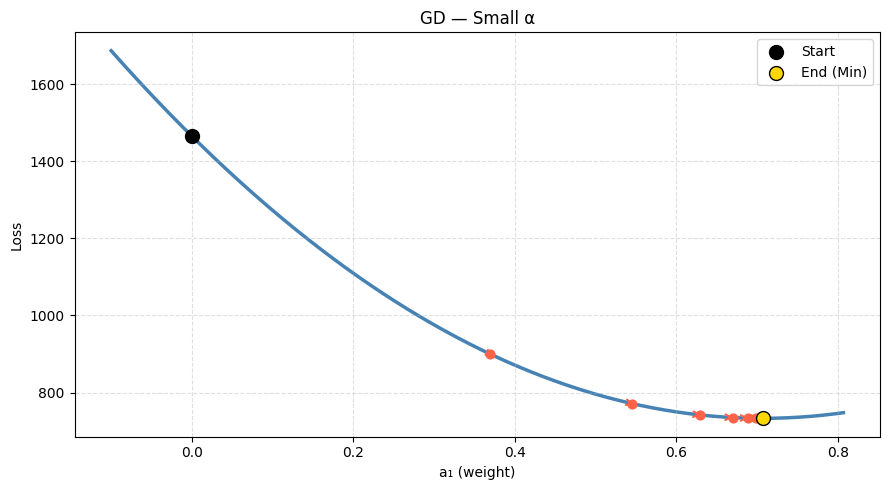

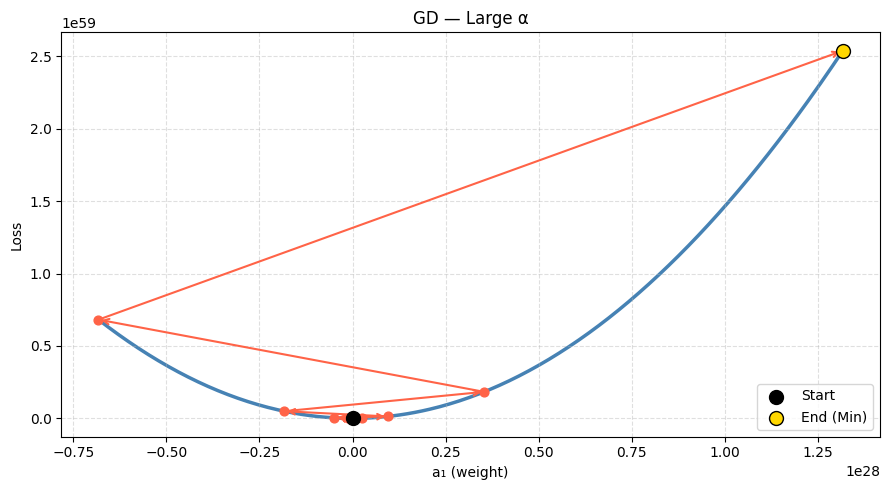

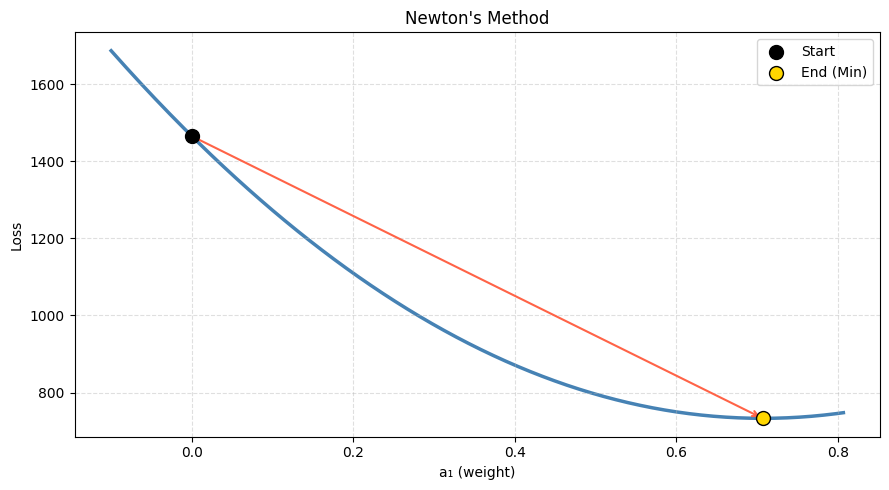

In [17]:
plot_loss_path(gd_history,        title="GD — Good α",    step=5)
plot_loss_path(gd_history_small,  title="GD — Small α",   step=50)
plot_loss_path(gd_history_large,  title="GD — Large α",   step=1)
plot_loss_path(nm_history,        title="Newton's Method", step=1)